# Marketing Analytics Challenge | Belén Alvariñas

In [309]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [317]:
data = pd.read_csv('data/bank-additional-full.csv', sep = ';')
print(data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

# Analisis Exploratorio de Datos

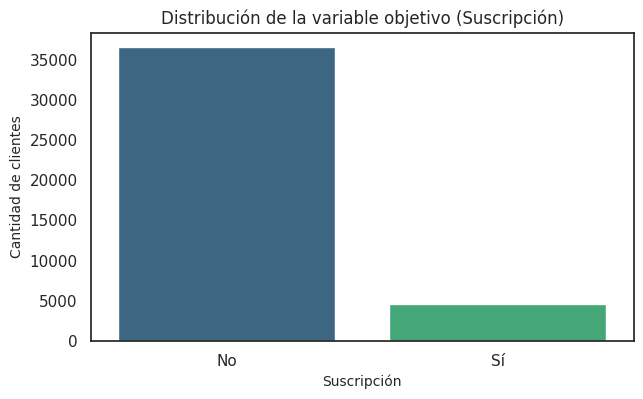

In [323]:
plt.figure(figsize=(7, 4))
orden = ['no', 'yes']
ax = sns.countplot(x='y', data=data, hue = 'y', palette='viridis')
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(['No', 'Sí'])

plt.title('Distribución de la variable objetivo (Suscripción)', fontsize=12)
plt.xlabel('Suscripción', fontsize=10)
plt.ylabel('Cantidad de clientes', fontsize=10)
plt.show()

In [311]:
counts = data['y'].value_counts()

percentages = data['y'].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje %': percentages.round(2)
})
print(resumen_target)


     Cantidad  Porcentaje %
y                          
no      36548         88.73
yes      4640         11.27


Como se observa en este gráfico y en los porcentajes calculados, la variable objetivo 'y' presenta un gran **desbalance de clases**: la clase mayoritaria, con el 89%,  corresponde a la negativa, frente a un 11% de suscripciones exitosas.

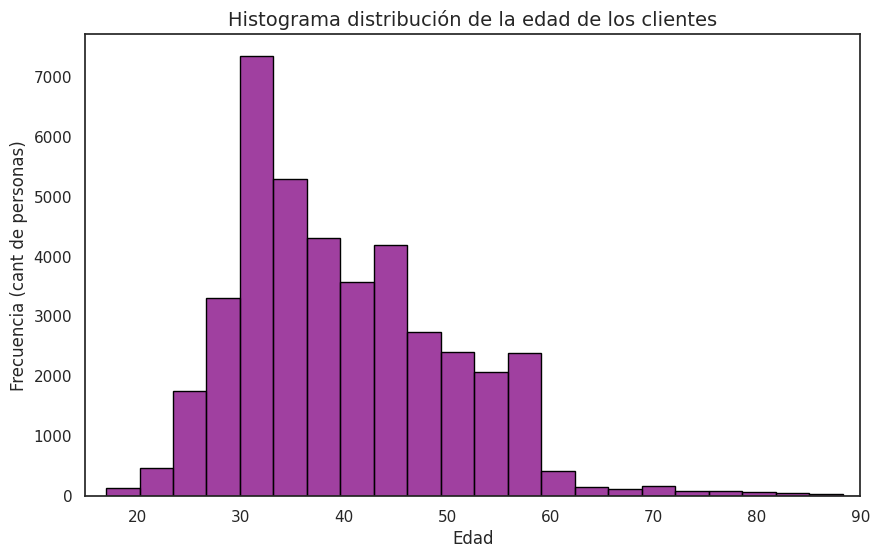

In [313]:
plt.figure(figsize=(10, 6))

sns.histplot(data=data, x='age', bins=25, color= 'purple', edgecolor='black')

plt.title('Histograma distribución de la edad de los clientes', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia (cant de personas)', fontsize=12)
plt.xlim(15, 90)

plt.show()

La mayor densidad de clientes se observa en el rango de **30 a 40 años**, lo que sugiere que la campaña se dirigió principalmente a este rango.

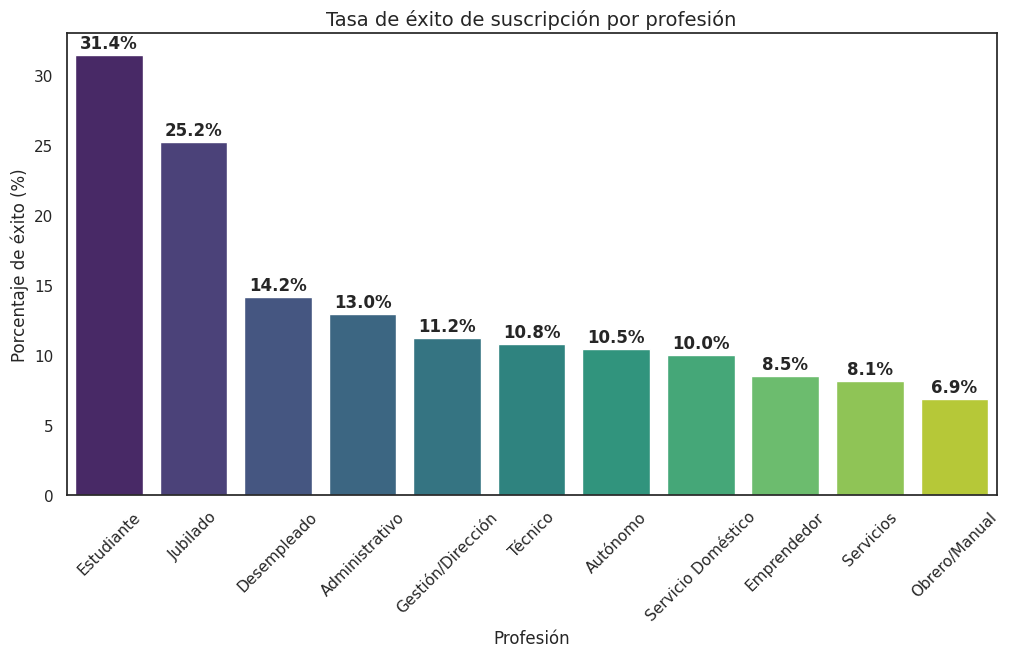

In [327]:
perfil_trabajo = data.groupby('job')['y'].value_counts(normalize=True).unstack() * 100
perfil_trabajo = perfil_trabajo.drop('unknown')
perfil_trabajo = perfil_trabajo.sort_values(by='yes', ascending=False)


traduccion_empleos = {
    'admin.': 'Administrativo', 'blue-collar': 'Obrero/Manual', 'entrepreneur': 'Emprendedor',
    'housemaid': 'Servicio Doméstico', 'management': 'Gestión/Dirección', 'retired': 'Jubilado',
    'self-employed': 'Autónomo', 'services': 'Servicios', 'student': 'Estudiante',
    'technician': 'Técnico', 'unemployed': 'Desempleado'
}

perfil_trabajo.index = [traduccion_empleos.get(x, x) for x in perfil_trabajo.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=perfil_trabajo.index, y=perfil_trabajo['yes'], hue=perfil_trabajo.index, palette='viridis', legend=False)

plt.title('Tasa de éxito de suscripción por profesión', fontsize=14)
plt.xlabel('Profesión', fontsize=12)
plt.ylabel('Porcentaje de éxito (%)', fontsize=12)

for i, valor in enumerate(perfil_trabajo['yes']):
    if not pd.isna(valor):
        plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.show()

La mayor tasa de éxito se observa en las profesiones **estudiantes, jubilados y desempleados**.

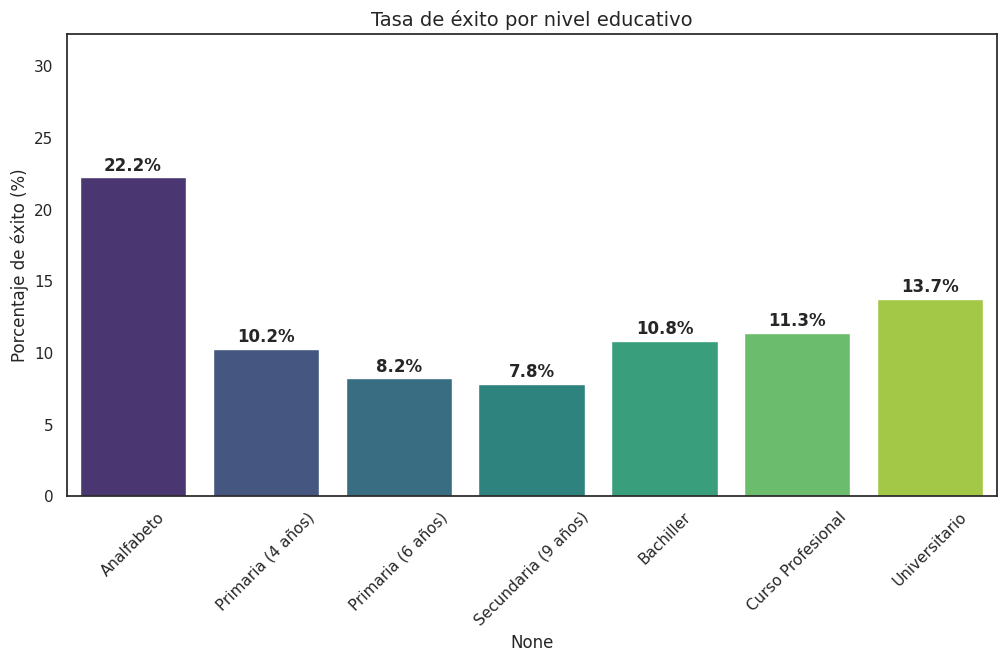

In [329]:
traduccion_edu = {
    'illiterate': 'Analfabeto',
    'basic.4y': 'Primaria (4 años)',
    'basic.6y': 'Primaria (6 años)',
    'basic.9y': 'Secundaria (9 años)',
    'high.school': 'Bachiller',
    'professional.course': 'Curso Profesional',
    'university.degree': 'Universitario'
}

orden_estudios = ['illiterate','basic.4y', 'basic.6y', 'basic.9y', 'high.school', 
                  'professional.course', 'university.degree']

df_edu = data[data['education'] != 'unknown']
perfil_edu = df_edu.groupby('education', observed=False)['y'].value_counts(normalize=True).unstack() * 100

perfil_edu = perfil_edu.reindex(orden_estudios)
perfil_edu.index = [traduccion_edu.get(x, x) for x in perfil_edu.index]

plt.figure(figsize=(12, 6))

sns.barplot(x=perfil_edu.index, y='yes', data=perfil_edu, hue=perfil_edu.index, palette='viridis', legend=False)


for i, valor in enumerate(perfil_edu['yes']):
    if not pd.isna(valor):
        plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.title('Tasa de éxito por nivel educativo', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Porcentaje de éxito (%)')
plt.ylim(0, perfil_edu['yes'].max() + 10)

plt.show()

La mayor tasa de éxito se observa en los clientes **analfabetos**, seguido de los perfiles con **formación especializada**, con títulos universitarios y cursos profesionales, lo que sugiere que hay mayor éxito en los extremos del espectro educativo.

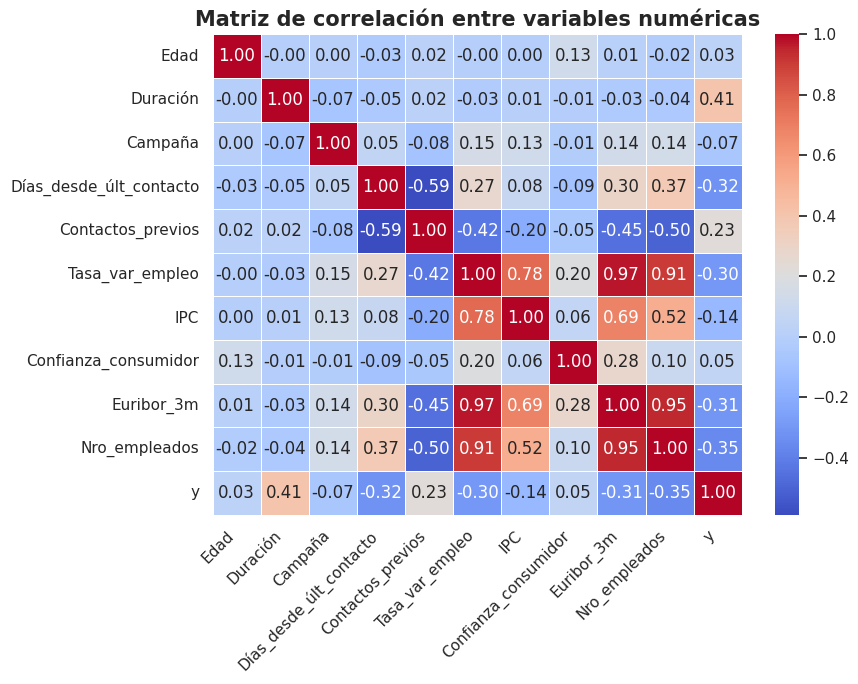

In [337]:
data_corr = data.copy()
data_corr['y'] = data_corr['y'].map({'yes': 1, 'no': 0})


traduccion_columnas = {
    'age': 'Edad',
    'duration': 'Duración',
    'campaign': 'Campaña',
    'pdays': 'Días_desde_últ_contacto',
    'previous': 'Contactos_previos',
    'emp.var.rate': 'Tasa_var_empleo',
    'cons.price.idx': 'IPC',
    'cons.conf.idx': 'Confianza_consumidor',
    'euribor3m': 'Euribor_3m',
    'nr.employed': 'Nro_empleados',
    'y': 'y'
}


data_corr = data_corr.rename(columns=traduccion_columnas)

plt.figure(figsize=(9, 7))

sns.heatmap(data_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Matriz de correlación entre variables numéricas", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

En el gráfico de heatmap de correlaciones se observa que los **indicadores económicos** (Euribor, tasas de empleo) presentan la mayor correlación negativa con el éxito de la suscripción, sugiriendo que el entorno económico es un factor importante en el comportamiento del consumidor.
La mayor correlación positiva se obtuvo para la variable duration, esta no se considerará en el análisis, ni en las predicciones, dado que la duración de la llamada no se conoce antes de realizar el contacto, incluirla generaría que el modelo no logre generalizar para nuevas instancias.

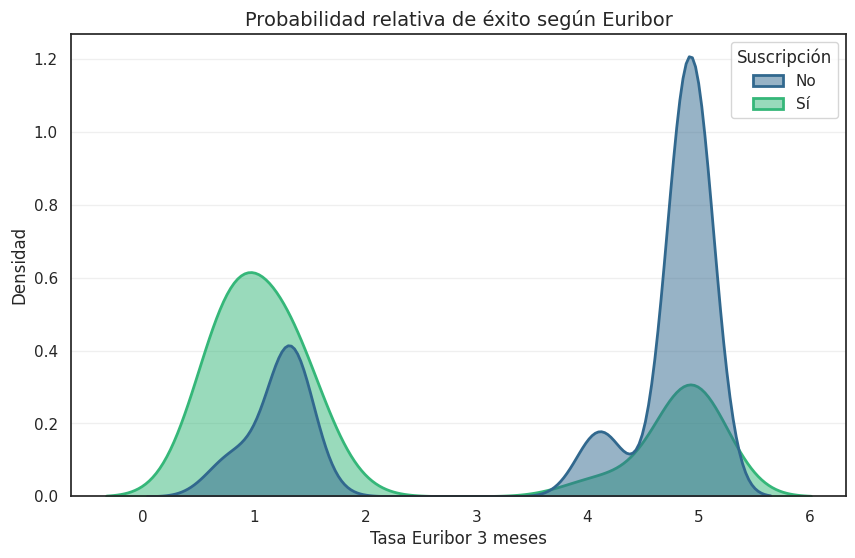

In [333]:
plt.figure(figsize=(10, 6))
data_temp = data.copy()
data_temp['Suscripción'] = data_temp['y'].map({'yes': 'Sí', 'no': 'No'})

sns.kdeplot(data=data_temp, x='euribor3m', hue='Suscripción', fill=True, 
            common_norm=False, palette='viridis', alpha=0.5, linewidth=2)

plt.title('Probabilidad relativa de éxito según Euribor', fontsize=14)
plt.xlabel('Tasa Euribor 3 meses', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

Al considerar la distribución de la tasa Euribor a 3 meses en relación con la variable objetivo, se observa una segmentación bimodal. Las suscripciones **no exitosas** se concentran en niveles de **tasas altas**, mientras que las suscripciones exitosas muestran una densidad mayor cuando la tasa se sitúa en niveles bajos.

# Modelos de Clasificación

## Preprocesamiento

In [ ]:
# datos faltantes
cols_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in cols_unknown:
    cantidad = (data[col] == 'unknown').sum()
    porcentaje = (cantidad / len(data)) * 100
    print(f"{col}: {cantidad} valores faltantes, {porcentaje:.2f}%")

filas_con_al_menos_un_unknown = data[cols_unknown].apply(lambda x: x == 'unknown').any(axis=1).sum()
porcentaje_total = (filas_con_al_menos_un_unknown / len(data)) * 100

print(f"porcentaje de filas con algún dato unknown: {porcentaje_total:.2f}%")

job: 330 valores faltantes, 0.80%
marital: 80 valores faltantes, 0.19%
education: 1731 valores faltantes, 4.20%
default: 8597 valores faltantes, 20.87%
housing: 990 valores faltantes, 2.40%
loan: 990 valores faltantes, 2.40%
porcentaje de filas con algún dato unknown: 25.98%


In [ ]:
# one-hot encoding
data['y'] = data['y'].map({'yes': 1, 'no': 0})
df_final = pd.get_dummies(data)

In [ ]:
X = df_final.drop(['y', 'duration'], axis=1)
y = df_final['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=125, stratify=y)


El preprocesamiento inició con un análisis de valores faltantes por categoría. Se determinó que estos representaban aproximadamente el 25% del dataset, por lo que se descartó su eliminación para preservar la información y evitar sesgos por pérdida de datos. Posteriormente, se aplicó una codificación **One-Hot Encoding** para transformar las variables categóricas en un formato apto para el entrenamiento de los modelos. Finalmente, se realizó una partición de datos bajo una proporción 80/20, reservando el 20% para una evaluación con datos no vistos durante el entrenamiento.

## Regresión Logística

Como primer paso en la fase de modelado, implementé una **Regresión Logística**. Seleccioné este algoritmo debido a su eficiencia para problemas de clasificación binaria y su alta capacidad de interpretación, lo que permite identificar claramente cómo influyen distintos valores en la decisión del cliente.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)


In [ ]:
importancia_lr = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_lr.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print(importancia_lr.head(5))

          Variable  Coeficiente
5   cons.price.idx     1.149548
7        euribor3m     0.647714
8      nr.employed     0.354017
45       month_aug     0.252699
49       month_mar     0.197980


El modelo identificó que los principales predictores del éxito son **factores económicos**. Destaca el Índice de Precios al Consumidor, como la variable de mayor peso, seguida por el Euribor a 3 meses y el Nivel de Empleo. Esto sugiere que la disposición de los clientes a contratar depósitos no depende únicamente de su perfil, sino que está condicionado por el entorno económico y las tasas de interés del mercado.

#### Resultados

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Métricas Regresión Logística:")
print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")

Métricas Regresión Logística:
Accuracy:  0.8348
Precision: 0.3634
Recall:    0.6207
F1-Score:  0.4584


## Random Forest

In [290]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=125, class_weight='balanced')

modelo_rf.fit(X_train, y_train)

y_pred = modelo_rf.predict(X_test)

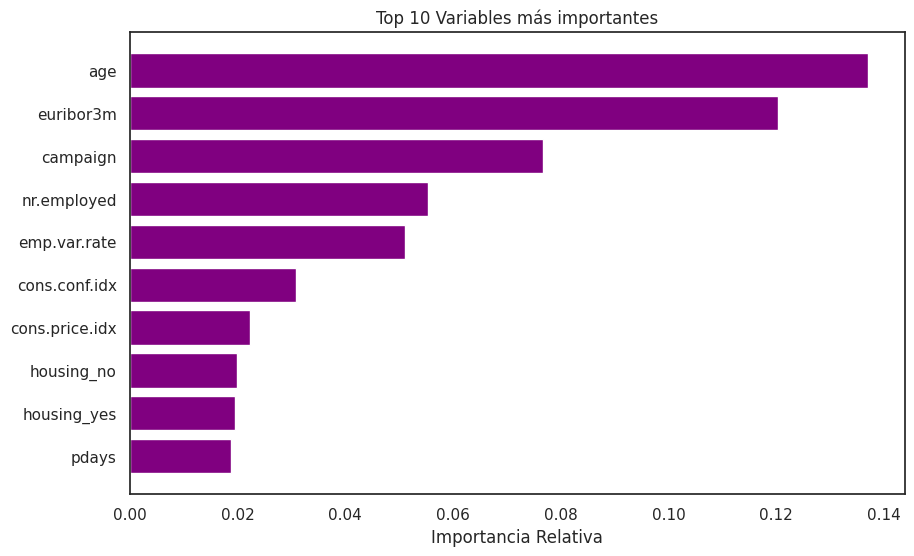

In [291]:
importancias = modelo_rf.feature_importances_
indices = np.argsort(importancias)[-10:]  

plt.figure(figsize=(10, 6))
plt.title('Top 10 Variables más importantes')
plt.barh(range(len(indices)), importancias[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()

Al transicionar hacia un modelo de Random Forest, se observa un cambio en la jerarquía de las variables. A diferencia de la Regresión Logística, este modelo identifica a la **edad** como el predictor principal. Random Forest es capaz de capturar interacciones más complejas y no lineales entre las variables que la regresión lineal no lograba capturar por completo. 
Junto a la edad, le siguen las variables de gestión como el **número de contactos realizados (campaign)** y **factores económicos (euribor3m)**.

#### Resultados

In [292]:
acc_rf = precision_score(y_test, y_pred)
prec_rf= precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print(f"Métricas Random Forest")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

Métricas Random Forest
Accuracy: 0.5664
Precision: 0.5664
Recall:    0.2759
F1-Score:  0.3710


## XGBOOST

A continuación, utilicé el modelo XGBoost ya que utiliza una estrategia de boosting, donde cada nuevo árbol se entrena para corregir los errores de los árboles previos. 

In [293]:
model_xgb = XGBClassifier(scale_pos_weight=8, random_state=125, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)


#### Resultados

In [294]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)


print(f"Métricas XGBoost:")
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")

Métricas XGBoost:
Accuracy:  0.8396
Precision: 0.3700
Recall:    0.6024
F1-Score:  0.4584


## SMV

El último modelo utilizad fue SVM, que busca el hiperplano óptimo que separa las clases y es efectivo en espacios de gran dimensionalidad.

In [295]:
model_svm = SVC(kernel='rbf', class_weight='balanced', random_state=125)
model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)


In [296]:
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)


print(f"Métricas SVM :")
print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")

Métricas SVM :
Accuracy:  0.8519
Precision: 0.3960
Recall:    0.5991
F1-Score:  0.4768


# Conlusiones

In [297]:

data_resultados = {
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb, acc_svm],
    'Precision': [prec_lr, prec_rf, prec_xgb, prec_svm],
    'Recall': [rec_lr, rec_rf, rec_xgb, rec_svm],
    'F1-Score': [f1_lr, f1_rf, f1_xgb, f1_svm]
}

df_final = pd.DataFrame(data_resultados)

df_final = df_final.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("TABLA COMPARATIVA DE RENDIMIENTO FINAL")
print("-" * 55)
print(df_final.to_string(index=False, formatters={'Accuracy': '{:.4f}'.format, 'Precision': '{:.4f}'.format, 'Recall': '{:.4f}'.format, 'F1-Score': '{:.4f}'.format}))


TABLA COMPARATIVA DE RENDIMIENTO FINAL
-------------------------------------------------------
             Modelo Accuracy Precision Recall F1-Score
                SVM   0.8519    0.3960 0.5991   0.4768
Regresión Logística   0.8348    0.3634 0.6207   0.4584
            XGBoost   0.8396    0.3700 0.6024   0.4584
      Random Forest   0.5664    0.5664 0.2759   0.3710


Para la interpretación de los resultados, hay que recordar que se trabajó con un gran desbalance de clases. En este escenario, la métrica de Accuracy puede resultar engañosa, ya que no refleja fielmente la capacidad predictiva del modelo sobre la clase minoritaria (los clientes que sí se suscriben).

Por este motivo, el análisis se centró en métricas más robustas:

   * Precision: Que penaliza los Falsos Positivos (clientes identificados erróneamente como interesados).

   * Recall: Que penaliza los Falsos Negativos (clientes potenciales que el modelo no logró identificar).

   * F1-Score: Que es un balance entre las métricas anteriores y es la técnica más utilizada para comparar modelos en contextos desbalanceados.

Sin embargo, la elección del modelo óptimo dependerá de los objetivos de negocio del cliente. Si el interés principal es minimizar los Falsos Negativos, es decir, no perder ninguna oportunidad de venta aunque esto implique contactar a personas que finalmente no contraten, el modelo de Regresión Logística, que es la mejor opción debido a su alto desempeño en Recall. Por el contrario, si se busca optimizar los recursos y contactar solo a quienes tienen una alta probabilidad de suscripción, Random Forest es superior por su nivel de Precisión.

Finalmente, si el objetivo es elegir un modelo que logre un equilibrio, el modelo SVM sería la elección más sólida al ofrecer el mejor balance general (F1).